In [15]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

# =========================
# CONFIG
# =========================
TS = 0.07
TIME_STEPS = 20
BATCH_SIZE = 32
EPOCHS = 100

DATA_PATH = "./Data/Datasets.xlsx"

TARGET_NAME = "Y"
PREDICTORS = ["PwmD", "PwmE", "sPwm", "dPwm", "sinTheta"]

TITLES = ["Train_1", "Train_2", "Val_1", "Val_2", "Test_1", "Test_2", "LSG_1", "LSG_2"]


In [16]:
# =========================
# SLIDING WINDOW
# =========================
def create_sequences(pred, target, time_steps):
    Xs, ys = [], []
    for i in range(len(pred) - time_steps):
        Xs.append(pred[i:i+time_steps])
        ys.append(target[i+time_steps])
    return np.array(Xs), np.array(ys)

# =========================
# LOAD TREINO
# =========================
df_train = pd.concat([
    pd.read_excel(DATA_PATH, sheet_name="Train_1"),
    pd.read_excel(DATA_PATH, sheet_name="Train_2")
])

Out_train = df_train[TARGET_NAME].values
dOut_train = df_train[f"d{TARGET_NAME}"].values

Inp_train = df_train[PREDICTORS].values

# =========================
# LOAD VAL
# =========================
df_val = pd.concat([
    pd.read_excel(DATA_PATH, sheet_name="Val_1"),
    pd.read_excel(DATA_PATH, sheet_name="Val_2")
])

dOut_val = df_val[f"d{TARGET_NAME}"].values
Inp_Val = df_val[PREDICTORS].values

# =========================
# NORMALIZAÇÃO 
# =========================
InpScaler = StandardScaler()
OutScaler = StandardScaler()

Inp_train = InpScaler.fit_transform(Inp_train)
Out_train = OutScaler.fit_transform(dOut_train.reshape(-1, 1)).flatten()

Inp_val = InpScaler.transform(Inp_Val)
Out_val  = OutScaler.transform(dOut_val.reshape(-1, 1)).flatten()

# =========================
# Sequencias 
# =========================

Inp_train, Out_train = create_sequences(Inp_train, Out_train, TIME_STEPS)
Inp_val, Out_val = create_sequences(Inp_val, Out_val, TIME_STEPS)

# =========================
# MODELO (dinâmico)
# =========================
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(TIME_STEPS, len(PREDICTORS))),
    tf.keras.layers.SimpleRNN(32, activation='tanh'),
    tf.keras.layers.Dense(1, activation='linear')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='mse'
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',     
    patience=10,            
    restore_best_weights=True,  
    verbose=1
)

history = model.fit(
    Inp_train,
    Out_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(Inp_val, Out_val),
    callbacks=[early_stop]
)

Epoch 1/100
61/61 [==============================] - 2s 11ms/step - loss: 0.2464 - val_loss: 0.1367
Epoch 2/100
61/61 [==============================] - 0s 6ms/step - loss: 0.0888 - val_loss: 0.0680
Epoch 3/100
61/61 [==============================] - 0s 6ms/step - loss: 0.0412 - val_loss: 0.0392
Epoch 4/100
61/61 [==============================] - 0s 6ms/step - loss: 0.0282 - val_loss: 0.0377
Epoch 5/100
61/61 [==============================] - 0s 6ms/step - loss: 0.0233 - val_loss: 0.0291
Epoch 6/100
61/61 [==============================] - 0s 6ms/step - loss: 0.0199 - val_loss: 0.0298
Epoch 7/100
61/61 [==============================] - 0s 6ms/step - loss: 0.0174 - val_loss: 0.0234
Epoch 8/100
61/61 [==============================] - 0s 6ms/step - loss: 0.0158 - val_loss: 0.0260
Epoch 9/100
61/61 [==============================] - 0s 6ms/step - loss: 0.0135 - val_loss: 0.0217
Epoch 10/100
61/61 [==============================] - 0s 6ms/step - loss: 0.0122 - val_loss: 0.0207
Epoch 11

Train_1 | R2 dOut_test: 0.9822 | R2 Theta: 0.9949
Train_2 | R2 dOut_test: 0.9937 | R2 Theta: 0.9942
Val_1 | R2 dOut_test: 0.9755 | R2 Theta: 0.9982
Val_2 | R2 dOut_test: 0.9838 | R2 Theta: 0.9724
Test_1 | R2 dOut_test: 0.6434 | R2 Theta: 0.3583
Test_2 | R2 dOut_test: 0.7225 | R2 Theta: 0.3250
LSG_1 | R2 dOut_test: 0.4698 | R2 Theta: -1.6759
LSG_2 | R2 dOut_test: 0.4504 | R2 Theta: -0.6856


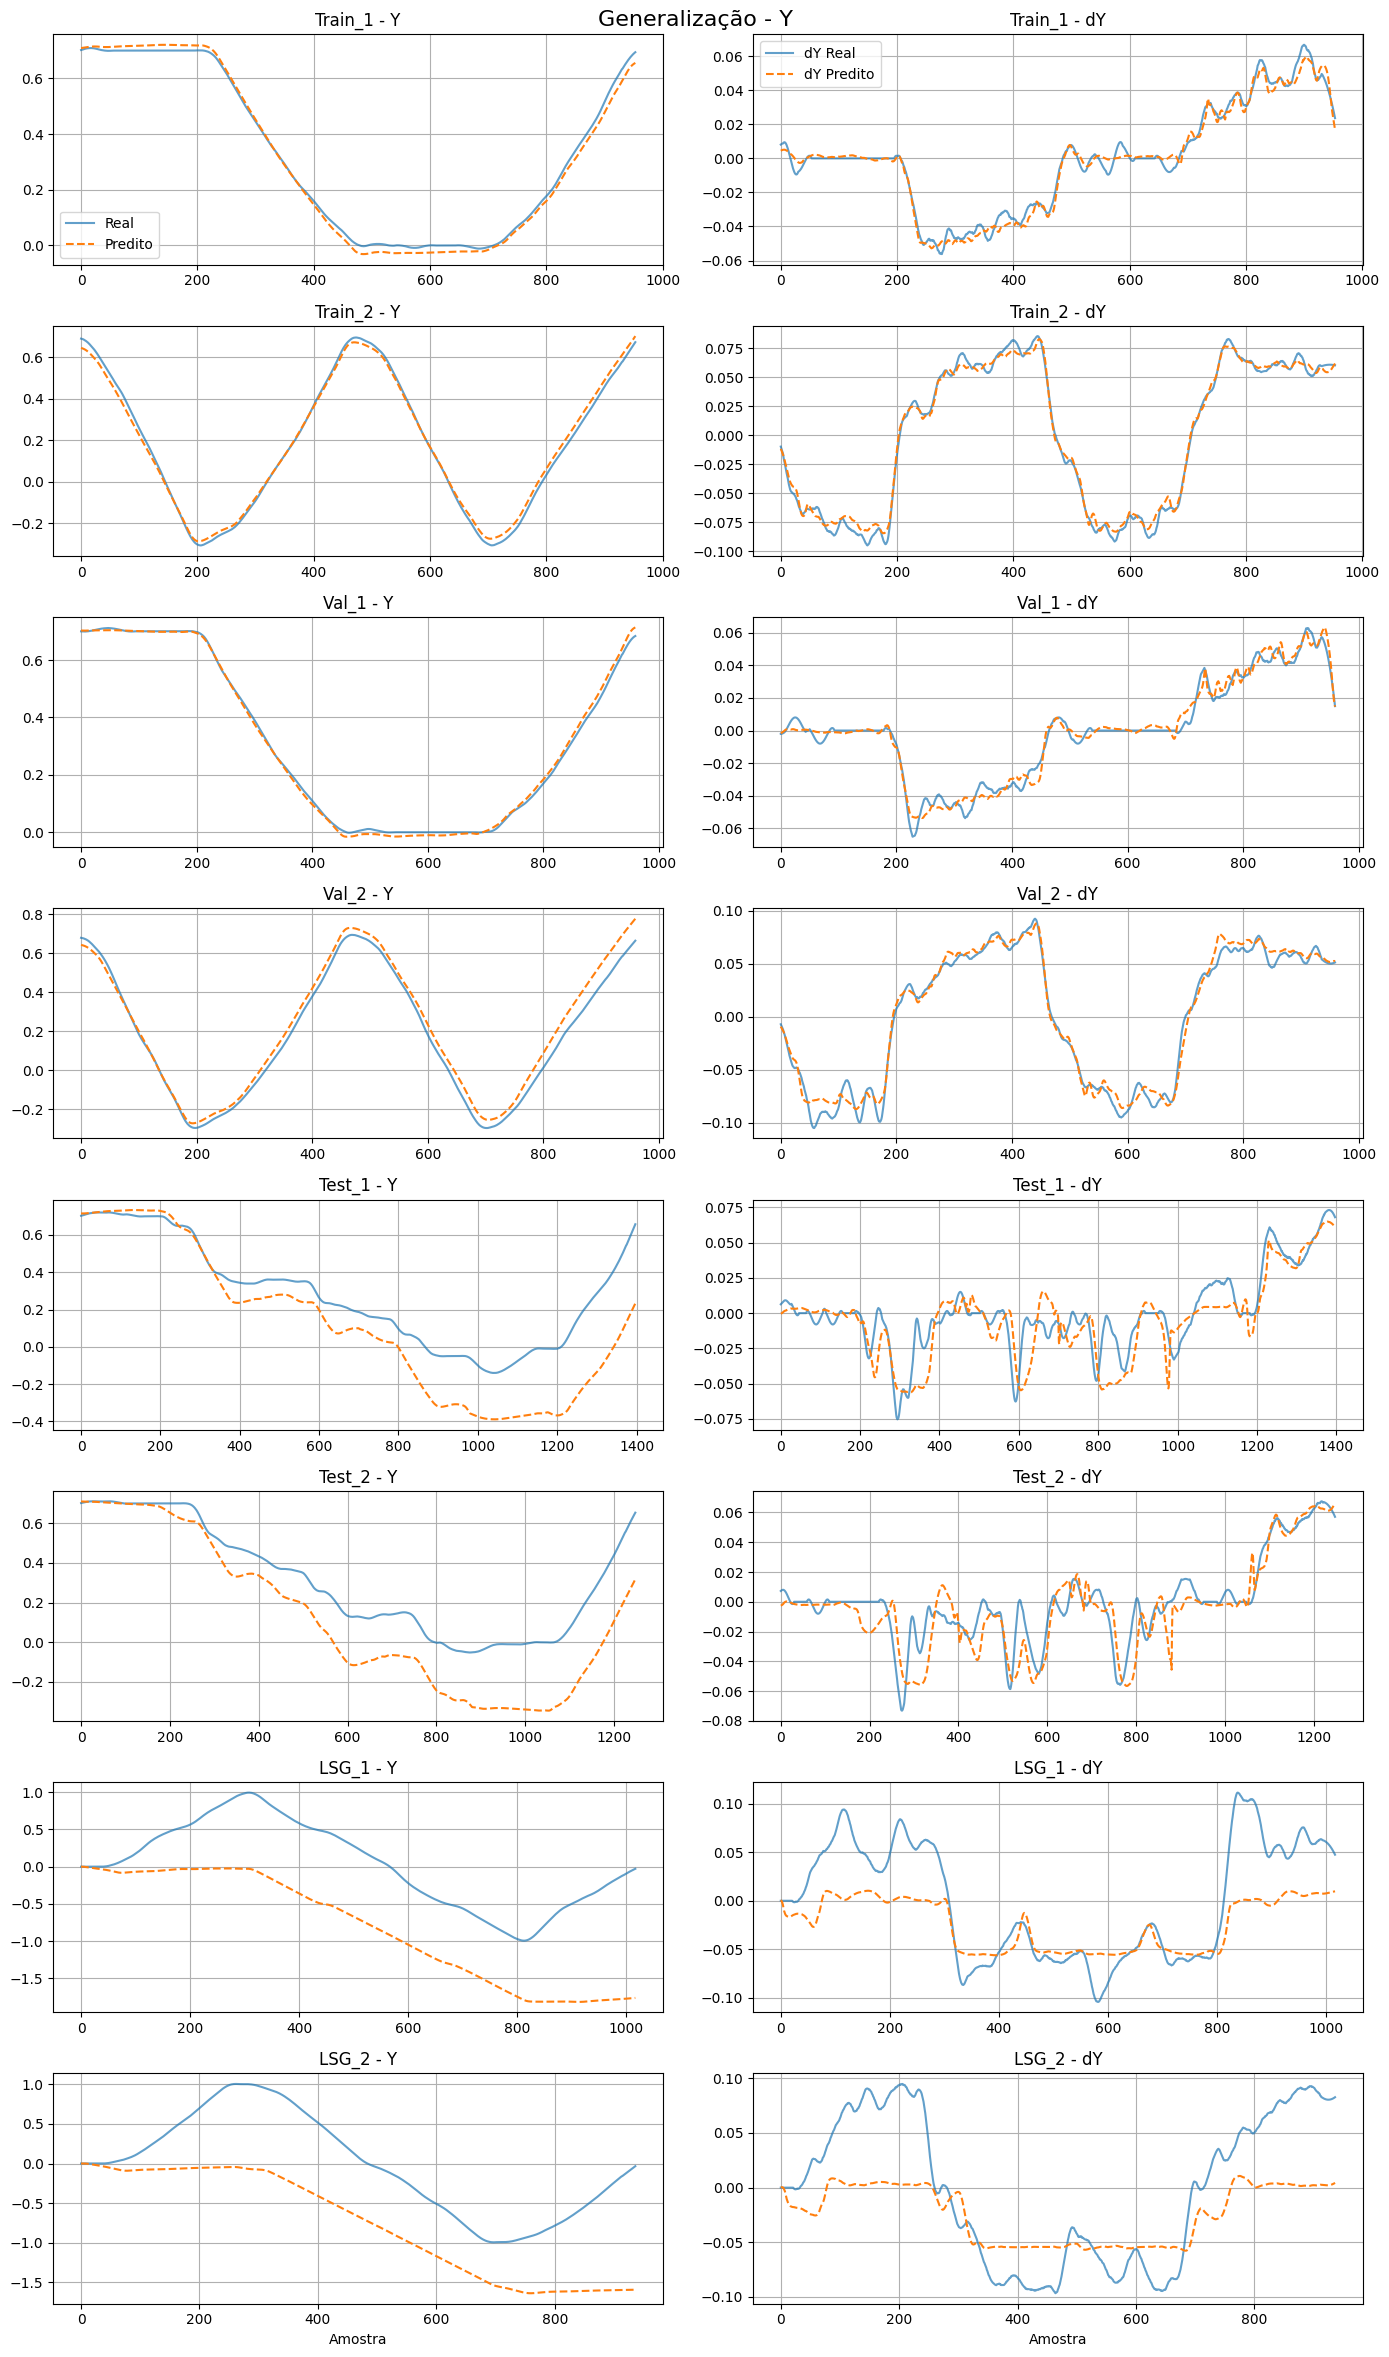

In [17]:
# =========================
# Teste
# =========================
n = len(TITLES)
fig, axs = plt.subplots(n, 2, figsize=(14, 3*n))

for i, title in enumerate(TITLES):

    df_test = pd.read_excel(DATA_PATH, sheet_name=title)

    Out_test_true = df_test[TARGET_NAME].values
    dOut_test_true = df_test[f"d{TARGET_NAME}"].values

    Inp_test = df_test[PREDICTORS].values

    Inp_test_scaled = InpScaler.transform(Inp_test)   
    Inp_test, Out_test_true = create_sequences(Inp_test_scaled, Out_test_true, TIME_STEPS)
    _, dOut_test_true = create_sequences(Inp_test_scaled, dOut_test_true, TIME_STEPS)
    
    # predição normalizada
    dOut_test_pred = model.predict(Inp_test, verbose=0)
    # predição desnormalizada
    dOut_test_pred = OutScaler.inverse_transform(dOut_test_pred)

    # =========================
    # RECONSTRUÇÃO 
    # =========================
    Out_test_true_0 = Out_test_true[TIME_STEPS:][0]
    Out_test_rec = np.zeros_like(Out_test_true.flatten())
    Out_test_pred = Out_test_true_0 + np.cumsum(dOut_test_pred.flatten() * TS)

    # =========================
    # PLOT TARGET
    # =========================
    axs[i, 0].plot(Out_test_true, label="Real", alpha=0.7)
    axs[i, 0].plot(Out_test_pred, label="Predito", linestyle='--')

    axs[i, 0].set_title(f"{title} - {TARGET_NAME}")
    axs[i, 0].grid(True)

    if i == 0:
        axs[i, 0].legend()

    # =========================
    # PLOT DERIVADA
    # =========================
    axs[i, 1].plot(dOut_test_true, label=f"d{TARGET_NAME} Real", alpha=0.7)
    axs[i, 1].plot(dOut_test_pred, label=f"d{TARGET_NAME} Predito", linestyle='--')

    axs[i, 1].set_title(f"{title} - d{TARGET_NAME}")
    axs[i, 1].grid(True)

    if i == 0:
        axs[i, 1].legend()
    r2_dOut_test = r2_score(dOut_test_true.flatten(), dOut_test_pred.flatten())
    r2_Out_test  = r2_score(Out_test_true.flatten(), Out_test_pred.flatten())
    print(f"{title} | R2 dOut_test: {r2_dOut_test:.4f} | R2 Theta: {r2_Out_test:.4f}")

axs[-1, 0].set_xlabel("Amostra")
axs[-1, 1].set_xlabel("Amostra")

plt.suptitle(f"Generalização - {TARGET_NAME}", fontsize=16)
plt.tight_layout()
plt.show()